# 15. Airborne lidar

`sylva.als` works on airborne (ALS) and UAV lidar delivered as tiles: a
catalogue built from the tile headers, ground classification and terrain and
canopy models over the whole catalogue, area-based metrics, individual tree
detection, and canopy structure from the pulses reconstructed with the flight
trajectory. Every catalogue function processes the area in chunks that each
carry a buffer of points from their neighbours, so the tile edges do not show
in the results. The guides are [Airborne lidar tiles](../guide/als.md),
[Area-based ALS metrics](../guide/als_metrics.md),
[Airborne trees](../guide/als_trees.md) and
[Canopy structure from airborne lidar](../guide/als_canopy.md).

Everything here is flown over synthetic scenes with `synthetic.als_flight`, so
the terrain, the trees and the plant area are known.

In [1]:
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import sylva
from sylva import synthetic

plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (7, 4), "axes.grid": False})
tmp = Path(tempfile.mkdtemp())      # files written here are temporary
from sylva import als

## A simulated flight

`als_flight` flies parallel lines over a scene with an oscillating mirror, a
beam of finite divergence sampled by sub-beams, and up to five returns per
pulse, each with the LAS attributes a real survey carries (`gps_time`,
`return_number`, `scan_angle`, `intensity`, the flight line in
`point_source_id`) and its true `classification`. The scene is 40 trees on a
gently sloping 100 m square; the trajectory is kept as a table.

In [2]:
rng = np.random.default_rng(0)
stems = [(x, y, 0.3, h) for x, y, h in
         zip(rng.uniform(5, 95, 40), rng.uniform(5, 95, 40), rng.uniform(10, 25, 40))]
scene = synthetic.forest(stems, size=100.0, ground_points=100, margin=0.0)
flight = synthetic.als_flight(scene, altitude=80.0, speed=10.0, line_spacing=40.0,
                              pulse_rate=50_000, bounds=(0, 0, 100, 100))
pts = flight.points
print(pts)
print(f"{flight.n_pulses:,} pulses fired; returns per pulse:",
      np.bincount(pts.attrs["number_of_returns"])[1:].tolist())
traj = flight.trajectory
print("trajectory columns:", list(traj), f"({len(traj['time']):,} samples)")

PointCloud(n=1,256,899, attrs=['classification', 'gps_time', 'intensity', 'number_of_returns', 'point_source_id', 'return_number', 'scan_angle', 'tree_id'])
1,800,000 pulses fired; returns per pulse: [1003812, 212416, 38048, 2573, 50]
trajectory columns: ['time', 'x', 'y', 'z', 'roll', 'pitch', 'heading', 'line'] (3,603 samples)


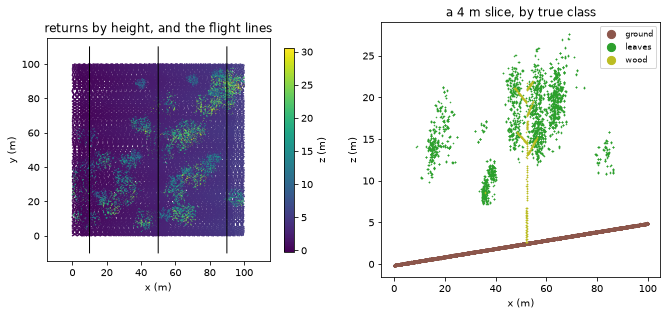

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.6), dpi=72)
s = pts[::20]
sc = ax[0].scatter(s.x, s.y, c=s.z, s=0.3, cmap="viridis")
for line in np.unique(traj["line"]):
    k = traj["line"] == line
    ax[0].plot(traj["x"][k], traj["y"][k], "k", lw=1)
ax[0].set(aspect="equal", xlim=(-15, 115), ylim=(-15, 115), xlabel="x (m)", ylabel="y (m)",
          title="returns by height, and the flight lines")
fig.colorbar(sc, ax=ax[0], shrink=0.8, label="z (m)")
slab = (pts.y > 48) & (pts.y < 52)
for c, colour, name in ((2, "tab:brown", "ground"), (4, "tab:green", "leaves"), (5, "tab:olive", "wood")):
    k = slab & (pts.attrs["classification"] == c)
    ax[1].scatter(pts.x[k], pts.z[k], s=0.3, c=colour, label=name)
ax[1].set(xlabel="x (m)", ylabel="z (m)", title="a 4 m slice, by true class")
ax[1].legend(markerscale=15, fontsize=8);

## Tiles and the catalogue

The returns are written as four 50 m LAZ tiles. `als.catalog` reads only the
headers and checks the tiling (overlaps, gaps, mixed coordinate systems,
point formats or scales) before anything is processed.

In [4]:
cat = flight.write_tiles(tmp / "tiles", size=50.0, epsg=32755)
print(cat.report())

ALS catalogue: 4 tiles, 1,256,899 points
  extent   x 0.00 .. 100.00, y 0.00 .. 100.00, z -0.24 .. 33.47
  area     0.0100 km² covered by tile extents (100.0 x 100.0 m bounding box)
  density  125.69 points/m²
  tiles    50.0 m across (median), 289,958 to 325,473 points
  format   LAS 1.4 format 6 (4)
  index    0 of 4 with a spatial index
  crs      EPSG:32755
  checks   no problems found



## Ground, terrain and canopy height

`classify_ground` runs the cloth simulation filter chunk by chunk and writes
classified tiles; `dtm` and `chm` build rasters on one grid shared by the
whole catalogue. The true terrain is `synthetic.terrain_height`, so the DTM
error is known in every cell. `normalize` writes tiles with heights above
ground in place of z.

In [5]:
ground_cat = als.classify_ground(cat, tmp / "ground", method="csf", cloth_resolution=1.0)
dtm = als.dtm(ground_cat, resolution=1.0)
chm = als.chm(ground_cat, resolution=0.5)
err = dtm.data - synthetic.terrain_height(*dtm.cell_centers())
tin = als.dtm(ground_cat, resolution=1.0, method="tin")
err_tin = tin.data - synthetic.terrain_height(*tin.cell_centers())
for name, e in (("lowest", err), ("tin", err_tin)):
    print(f"DTM ({name:6s}) error: mean {e.mean() * 100:+.1f} cm, mean absolute {np.abs(e).mean() * 100:.1f} cm, "
          f"largest {np.abs(e).max() * 100:.0f} cm")
print(f"CHM: tallest {np.nanmax(chm.data):.1f} m; {np.mean(chm.data > 2):.0%} of the cells above 2 m")
norm = als.normalize(ground_cat, tmp / "normalised", replace_z=True)
h = norm.read((0, 0, 100, 100)).z
print(norm, f"| heights {h.min():.2f} to {h.max():.2f} m")

DTM (lowest) error: mean -6.8 cm, mean absolute 6.8 cm, largest 15 cm
DTM (tin   ) error: mean -0.0 cm, mean absolute 1.1 cm, largest 10 cm
CHM: tallest 29.9 m; 37% of the cells above 2 m


Catalog(4 tiles, 1,256,899 points) | heights -0.02 to 29.87 m


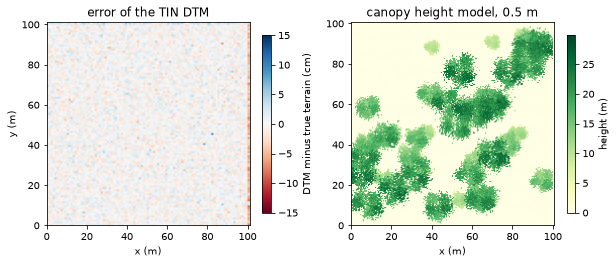

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=72)
ext = lambda r: (r.xmin, r.xmin + r.data.shape[1] * r.resolution, r.ymin, r.ymin + r.data.shape[0] * r.resolution)
im = ax[0].imshow(100 * err_tin, origin="lower", extent=ext(tin), cmap="RdBu", vmin=-15, vmax=15)
fig.colorbar(im, ax=ax[0], shrink=0.8, label="DTM minus true terrain (cm)")
ax[0].set(xlabel="x (m)", ylabel="y (m)", title="error of the TIN DTM")
im = ax[1].imshow(chm.data, origin="lower", extent=ext(chm), cmap="YlGn")
fig.colorbar(im, ax=ax[1], shrink=0.8, label="height (m)")
ax[1].set(xlabel="x (m)", title="canopy height model, 0.5 m");

The default DTM takes the lowest ground return in each cell, which lies
below the terrain at the cell centre: the terrain slopes by 5 %, so the lowest
point of a 1 m cell is about 2.5 cm below its centre, and the lowest of many
returns with 2 cm of range noise lies a few centimetres lower still. A TIN
through the ground returns (`method="tin"`) removes that bias.

## Area-based metrics

`grid_metrics` computes lidR's standard metrics (height percentiles, cover,
entropy and the rest; `als.metric_names()` lists them) on a grid over the
catalogue, and `plot_metrics` the same for plots, here four circles of 15 m
radius. With `min_height=0` the returns below the DTM are left out.

In [7]:
grid = als.grid_metrics(ground_cat, 20.0, ["zmax", "zq95", "cover", "zentropy"], min_height=0.0)
print("zq95 on a 20 m grid (m), south row first:")
print(np.round(grid["zq95"].data, 1))
plots = als.plot_metrics(ground_cat, [(25, 25), (75, 25), (25, 75), (75, 75)], radius=15.0,
                         metrics=["n", "zmax", "zq95", "zmean", "cover"], min_height=0.0,
                         ids=["SW", "SE", "NW", "NE"])
plots.to_pandas().round(2)

zq95 on a 20 m grid (m), south row first:
[[18.3 17.5 15.9 18.4  0.1  0. ]
 [19.  18.7 11.9 19.6 12.1  nan]
 [16.1 14.6 18.6 20.1  9.7  nan]
 [ 0.1 10.6 17.8 19.5 17.1  0.1]
 [ 0.1  0.1  4.8  8.4 19.8  0.1]
 [ nan  0.   nan  0.   nan  nan]]


,plot,id,n,zmax,zq95,zmean,cover
0,0,SW,97440.0,27.98,19.02,3.58,23.82
1,1,SE,96126.0,29.87,18.35,2.89,18.36
2,2,NW,80555.0,18.57,0.11,0.29,1.39
3,3,NE,96603.0,27.51,18.62,2.99,19.71


The north-west plot holds no tree centre, only the edge of a crown from
outside it, hence its low `zq95` and cover. The grid is anchored at the
catalogue's south-west corner, so its last row and column (north and east)
lie almost entirely beyond the survey and hold few returns or none.

## Individual trees

For tree detection the scene is `synthetic.crown_forest`: 100 trees on a
hectare with closed, ellipsoidal crowns of known size, flown at about 20
returns per m². `find_trees` finds tree tops with a local maximum filter on
the CHM (a window a fifth of the tree height) and grows crowns from them by
the method of Dalponte and Coomes (2016), and with `out` writes the tiles
again with a `tree_id` per point. `synthetic.forest_trees` gives the truth:
each tree's top, height and crown outline.

In [8]:
stand = synthetic.stand(100, size=100.0, min_spacing=3.0, heights=(10, 25), seed=11)
crowns = synthetic.crown_forest(stand, size=100.0, ground_points=100, margin=0.0, seed=11)
flight_2 = synthetic.als_flight(crowns, pulse_rate=4_000, line_spacing=30.0, bounds=(0, 0, 100, 100), seed=11)
cat_2 = flight_2.write_tiles(tmp / "stand", size=50.0, epsg=32755)

found = als.find_trees(cat_2, out=tmp / "labelled", method="dalponte2016",
                       window=als.LinearWindow(0.0, 0.2, 2.0, 20.0), max_cr=20)
truth = synthetic.forest_trees(crowns)
print(found, f"| {len(truth['tree_id'])} true trees | {len(flight_2.points):,} returns")
print(als.catalog(tmp / "labelled").report().splitlines()[0], "with a tree_id attribute")

Trees(127 trees) | 100 true trees | 200,143 returns
ALS catalogue: 4 tiles, 200,143 points with a tree_id attribute


Each top is assigned to the true tree of the highest return within
0.75 m of it, as in the guide's validation. A tree is found when at least one
top lies on it; every other top is a commission error (a second top on the
same tree, or a top on no tree).

In [9]:
p = flight_2.points
tid = p.attrs["tree_id"]
top_tree = np.zeros(len(found), int)
for i, (x, y) in enumerate(zip(found.x, found.y)):
    near = np.flatnonzero(np.hypot(p.x - x, p.y - y) < 0.75)
    top_tree[i] = tid[near[np.argmax(p.z[near])]] if len(near) else 0
hit = np.unique(top_tree[top_tree > 0])
first = np.array([np.flatnonzero(top_tree == t)[0] for t in hit])
row = np.searchsorted(truth["tree_id"], hit)
dh = found.height[first] - truth["height"][row]
print(f"found {len(hit)} of {len(truth['tree_id'])} trees ({len(hit) / len(truth['tree_id']):.0%}); "
      f"commission {1 - len(hit) / len(found):.0%} of the {len(found)} tops")
print(f"height of the trees found: bias {dh.mean():+.2f} m, RMSE {np.sqrt(np.mean(dh ** 2)):.2f} m")
ratio = found.crown_area[first] / truth["crown_area"][row]
print(f"crown area found / true crown area: median {np.median(ratio):.2f}")

found 71 of 100 trees (71%); commission 44% of the 127 tops
height of the trees found: bias -0.26 m, RMSE 0.59 m
crown area found / true crown area: median 0.73


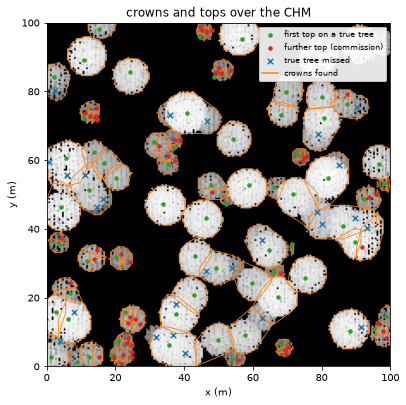

In [10]:
chm_2 = als.chm(cat_2, resolution=0.5)
fig, ax = plt.subplots(figsize=(6.5, 6.2), dpi=72)
ax.imshow(chm_2.data, origin="lower", extent=ext(chm_2), cmap="Greys_r")
for poly in found.crowns:
    if len(poly):
        ax.fill(*poly.T, fc="none", ec="C1", lw=0.8)
missed = np.setdiff1d(truth["tree_id"], hit)
k = np.searchsorted(truth["tree_id"], missed)
extra = np.setdiff1d(np.arange(len(found)), first)
ax.scatter(found.x[first], found.y[first], s=12, c="C2", label="first top on a true tree")
ax.scatter(found.x[extra], found.y[extra], s=12, c="C3", label="further top (commission)")
ax.scatter(truth["top_x"][k], truth["top_y"][k], marker="x", s=30, c="C0", label="true tree missed")
ax.plot([], [], c="C1", label="crowns found")
ax.set(xlim=(0, 100), ylim=(0, 100), xlabel="x (m)", ylabel="y (m)", title="crowns and tops over the CHM")
ax.legend(fontsize=8, loc="upper right", framealpha=0.9);

The trees missed are, with few exceptions, overtopped: a shorter tree whose
top lies under the crown of a taller neighbour is no local maximum in a
canopy surface, so no method working on the surface can find it. At about
20 returns per m² a crown's surface is ragged and has several local maxima,
which gives the further tops on the smaller crowns; the found crowns are
correspondingly smaller than the true ones. The validation in the guide shows how both change with
stand density and point density.

## Canopy structure from the pulses

Each airborne pulse is a ray from the aircraft down through the canopy.
`als.pulses` groups the returns of each pulse (by `gps_time` and flight line)
and starts it at the sensor position interpolated from the trajectory, which
gives a `Shots` object like those of a terrestrial scan. Its report shows
how well the trajectory fits: the returns of a multiple-return pulse lie on
one line through the sensor.

In [11]:
trajectory = als.Trajectory.from_dict(flight.trajectory)
shots, report = als.pulses(cat.read((0, 0, 50, 50)), trajectory, report=True)
print(shots)
print({k: report[k] for k in ("n_returns", "n_pulses", "n_incomplete", "n_missing_returns")},
      f"| sensor to return line: median {1000 * report['line_offset_median']:.1f} mm")

Shots(n_shots=282,600, n_echoes=322,827)
{'n_returns': 322827, 'n_pulses': 282600, 'n_incomplete': 2868, 'n_missing_returns': 3089} | sensor to return line: median 2.5 mm


Pulses are incomplete where the tile was cut: some of their returns fell
in the next tile. The catalogue functions below read each chunk with a buffer
so that they see whole pulses.

A known answer needs a scene whose plant area is known exactly: a layer of
5 cm spheres between 5 and 15 m, a turbid medium in which a thin beam is
stopped with probability `n π r²` per metre in any direction. That is the
extinction of spherical leaf angles (G = 0.5) at a plant area density of
`2 n π r²`, here 0.3 m² m⁻³, and so a plant area index of 3. One sub-beam
per pulse makes every pulse a single ray.

In [12]:
rng = np.random.default_rng(1)
n = 935_000
xyz = np.column_stack([rng.uniform(-15, 55, n), rng.uniform(-15, 55, n), rng.uniform(5, 15, n)])
layer = sylva.PointCloud(xyz, {"classification": np.full(n, 4, np.uint8)})
print(f"true PAD {2 * n / (70 * 70 * 10) * np.pi * 0.05 ** 2:.3f} m² m⁻³")
flight_3 = synthetic.als_flight(layer, altitude=60.0, line_spacing=20.0, footprint_samples=1,
                                target_radius=0.05, terrain_slope=0.0, bounds=(0, 0, 40, 40))
cat_3 = flight_3.write_tiles(tmp / "layer", size=20.0, epsg=32755)
traj_3 = als.Trajectory.from_dict(flight_3.trajectory)

prof = als.gap_profile(cat_3, traj_3, resolution=10.0, min_height=2.0, buffer=15.0)
inner = np.zeros(prof.shape[1:], bool)
inner[1:3, 1:3] = True                      # the central 20 m, away from the clipped edge
height, pad = prof.profile(inner)
print(f"gap profile: PAI {prof.pooled_pai(inner):.3f}, PAD 6-14 m {pad[(height >= 6) & (height < 14)].mean():.3f}")

vox = als.ray_voxelize(cat_3, traj_3, voxel_size=1.0, z_range=(-1, 19), buffer=15.0)
pai = vox.pai(min_beams=5)
cx, cy = pai.cell_centers()
middle = (cx > 10) & (cx < 30) & (cy > 10) & (cy < 30)
print(f"ray-traced voxels: median column PAI {np.nanmedian(pai.data[middle]):.3f}, "
      f"reach {vox.reach:.1f} m (within the 15 m buffer)")

true PAD 0.300 m² m⁻³


gap profile: PAI 2.992, PAD 6-14 m 0.300


ray-traced voxels: median column PAI 3.002, reach 11.9 m (within the 15 m buffer)


`gap_profile` inverts the Beer-Lambert law layer by layer from the returns
counted in each 10 m cell (the profile of MacArthur and Horn, with each
return's beam angle from the trajectory), and `ray_voxelize` traces every
pulse through a voxel lattice. Both recover the layer. The flight is clipped
to the 40 m square, so pulses whose ground return fell outside it lost their
last return and the cells along that edge read too dense, which is why the
example keeps to the middle.

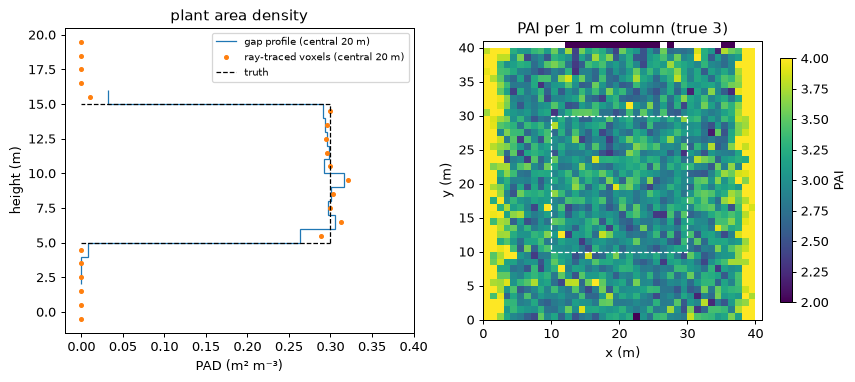

In [13]:
vh, vpad = vox.profile(min_beams=5, mask=middle)       # heights above the grid floor
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
ax[0].stairs(np.nan_to_num(pad), np.r_[height, height[-1] + prof.bin_size], orientation="horizontal",
             baseline=None, label="gap profile (central 20 m)")
ax[0].plot(vpad, vox.origin[2] + vh + 0.5, "o", ms=3, label="ray-traced voxels (central 20 m)")
ax[0].plot([0.3, 0.3, 0], [5, 15, 15], "k--", lw=1)
ax[0].plot([0, 0.3], [5, 5], "k--", lw=1, label="truth")
ax[0].set(xlabel="PAD (m² m⁻³)", ylabel="height (m)", xlim=(-0.02, 0.4), title="plant area density")
ax[0].legend(fontsize=8)
im = ax[1].imshow(pai.data, origin="lower", extent=ext(pai), cmap="viridis", vmin=2, vmax=4)
ax[1].plot([10, 30, 30, 10, 10], [10, 10, 30, 30, 10], "w--", lw=1)
fig.colorbar(im, ax=ax[1], shrink=0.8, label="PAI")
ax[1].set(xlabel="x (m)", ylabel="y (m)", title="PAI per 1 m column (true 3)");